# Online Payments (PaySim) Data Discovery


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## Load Data

In [3]:
DATA_PATH = Path('../data/raw/online_payments.csv')

if not DATA_PATH.exists():
    print(f"File not found: {DATA_PATH}")
    print("Download PaySim dataset from Kaggle and save it there.")
else:
    print(f"Loading from {DATA_PATH}")

Loading from ..\data\raw\online_payments.csv


In [4]:
# Load sample to inspect structure
df_sample = pd.read_csv(DATA_PATH, nrows=5000)
df_sample.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            5000 non-null   int64  
 1   type            5000 non-null   object 
 2   amount          5000 non-null   float64
 3   nameOrig        5000 non-null   object 
 4   oldbalanceOrg   5000 non-null   float64
 5   newbalanceOrig  5000 non-null   float64
 6   nameDest        5000 non-null   object 
 7   oldbalanceDest  5000 non-null   float64
 8   newbalanceDest  5000 non-null   float64
 9   isFraud         5000 non-null   int64  
 10  isFlaggedFraud  5000 non-null   int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 429.8+ KB


In [6]:
# Load full dataset
df = pd.read_csv(DATA_PATH)
print(f"Total transactions: {len(df):,}")

Total transactions: 6,362,620


##  Basic Statistics

In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [8]:
# Missing values
missing = df.isnull().sum()
if missing.any():
    print("Missing values:")
    print(missing[missing > 0])
else:
    print("No missing values.")

No missing values.


##  Transaction Types

In [9]:
type_counts = df['type'].value_counts()
print("Transaction types:")
for t, cnt in type_counts.items():
    print(f"  {t}: {cnt:,} ({cnt/len(df)*100:.2f}%)")

Transaction types:
  CASH_OUT: 2,237,500 (35.17%)
  PAYMENT: 2,151,495 (33.81%)
  CASH_IN: 1,399,284 (21.99%)
  TRANSFER: 532,909 (8.38%)
  DEBIT: 41,432 (0.65%)


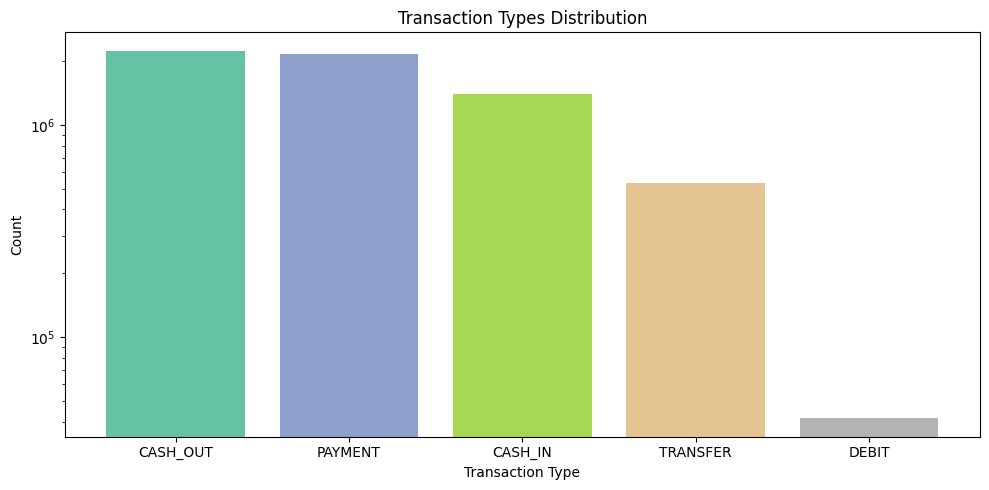

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(type_counts)))
ax.bar(type_counts.index, type_counts.values, color=colors)
ax.set_xlabel('Transaction Type')
ax.set_ylabel('Count')
ax.set_title('Transaction Types Distribution')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

CASH_OUT and PAYMENT dominate. TRANSFER transactions typically have higher fraud rates.

##  Fraud Analysis

In [11]:
fraud_counts = df['isFraud'].value_counts()
print(f"Legitimate: {fraud_counts[0]:,} ({fraud_counts[0]/len(df)*100:.4f}%)")
print(f"Fraud: {fraud_counts[1]:,} ({fraud_counts[1]/len(df)*100:.4f}%)")

Legitimate: 6,354,407 (99.8709%)
Fraud: 8,213 (0.1291%)


Extreme class imbalance - fraud is typically <0.2% of transactions. This is realistic for real-world fraud detection.

In [12]:
# Fraud rate by transaction type
fraud_by_type = df.groupby('type')['isFraud'].agg(['sum', 'count'])
fraud_by_type['rate'] = fraud_by_type['sum'] / fraud_by_type['count'] * 100
fraud_by_type.columns = ['fraud_count', 'total', 'fraud_rate_%']
fraud_by_type.sort_values('fraud_rate_%', ascending=False)

,fraud_count,total,fraud_rate_%
type,,,
TRANSFER,4097,532909,0.768799
CASH_OUT,4116,2237500,0.183955
CASH_IN,0,1399284,0.000000
DEBIT,0,41432,0.000000
PAYMENT,0,2151495,0.000000


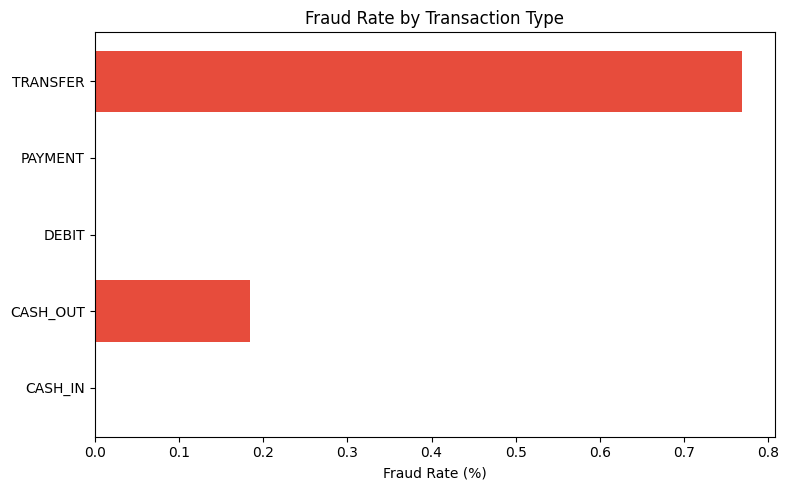

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if r > 0 else '#2ecc71' for r in fraud_by_type['fraud_rate_%']]
ax.barh(fraud_by_type.index, fraud_by_type['fraud_rate_%'], color=colors)
ax.set_xlabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Transaction Type')
plt.tight_layout()
plt.show()

Fraud is concentrated in TRANSFER and CASH_OUT types.

##  Amount Analysis

In [14]:
fraud_df = df[df['isFraud'] == 1]
legit_df = df[df['isFraud'] == 0]

print("Legitimate amounts:")
print(f"  Mean: {legit_df['amount'].mean():,.2f}")
print(f"  Median: {legit_df['amount'].median():,.2f}")

print("\nFraud amounts:")
print(f"  Mean: {fraud_df['amount'].mean():,.2f}")
print(f"  Median: {fraud_df['amount'].median():,.2f}")

Legitimate amounts:
  Mean: 178,197.04
  Median: 74,684.72

Fraud amounts:
  Mean: 1,467,967.30
  Median: 441,423.44


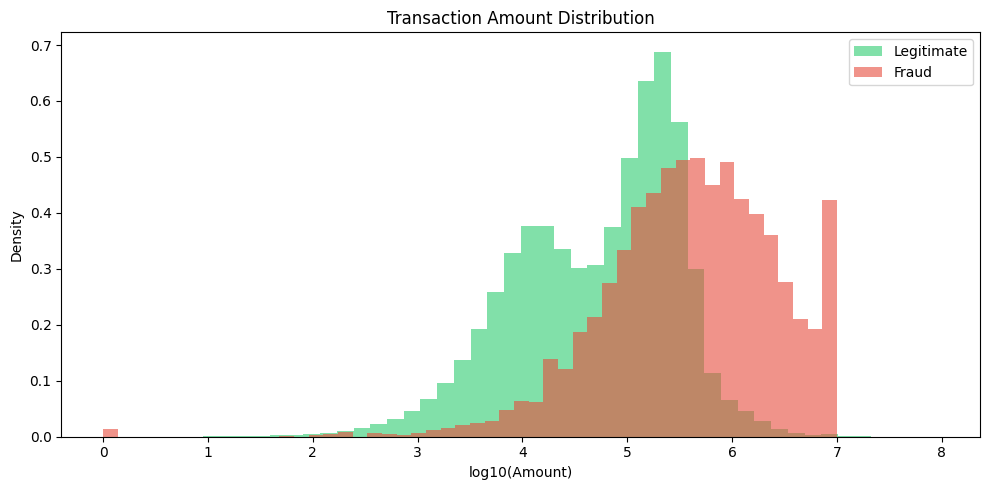

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(np.log10(legit_df['amount'].clip(lower=1)), bins=50, alpha=0.6, 
        label='Legitimate', color='#2ecc71', density=True)
ax.hist(np.log10(fraud_df['amount'].clip(lower=1)), bins=50, alpha=0.6, 
        label='Fraud', color='#e74c3c', density=True)
ax.set_xlabel('log10(Amount)')
ax.set_ylabel('Density')
ax.set_title('Transaction Amount Distribution')
ax.legend()
plt.tight_layout()
plt.show()

Fraud transactions tend to have higher amounts on average. Useful feature but not sufficient alone.

## Temporal Analysis

In [16]:
print(f"Time range: step {df['step'].min()} to {df['step'].max()}")
print(f"Duration: {df['step'].max() - df['step'].min()} hours")
print(f"Days: {(df['step'].max() - df['step'].min()) / 24:.1f}")

Time range: step 1 to 743
Duration: 742 hours
Days: 30.9


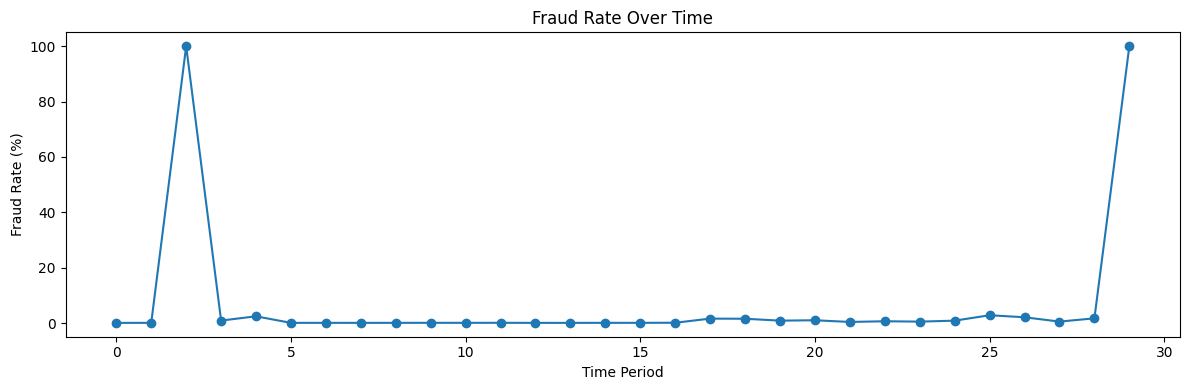

In [17]:
# Fraud rate over time
df['time_bin'] = pd.cut(df['step'], bins=30)
fraud_time = df.groupby('time_bin')['isFraud'].agg(['sum', 'count'])
fraud_time['rate'] = fraud_time['sum'] / fraud_time['count'] * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(len(fraud_time)), fraud_time['rate'], marker='o')
ax.set_xlabel('Time Period')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Fraud Rate Over Time')
plt.tight_layout()
plt.show()

Fraud rate varies over time, indicating temporal patterns that could be useful features.

##  Account Analysis

In [18]:
n_orig = df['nameOrig'].nunique()
n_dest = df['nameDest'].nunique()
n_all = pd.concat([df['nameOrig'], df['nameDest']]).nunique()

print(f"Origin accounts: {n_orig:,}")
print(f"Destination accounts: {n_dest:,}")
print(f"Total unique accounts: {n_all:,}")

Origin accounts: 6,353,307
Destination accounts: 2,722,362
Total unique accounts: 9,073,900


In [19]:
# Transactions per account
tx_per_acct = df.groupby('nameOrig').size()

print(f"Transactions per account:")
print(f"  Min: {tx_per_acct.min()}")
print(f"  Max: {tx_per_acct.max()}")
print(f"  Mean: {tx_per_acct.mean():.2f}")
print(f"  Median: {tx_per_acct.median():.0f}")

Transactions per account:
  Min: 1
  Max: 3
  Mean: 1.00
  Median: 1


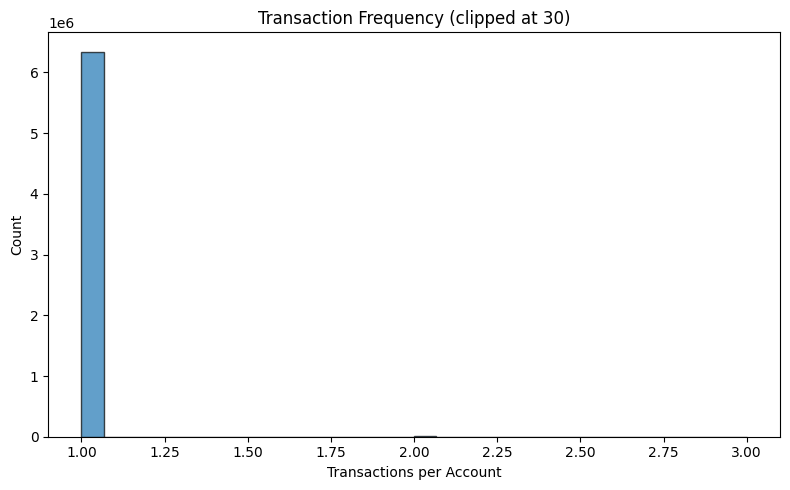

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(tx_per_acct.clip(upper=30), bins=30, edgecolor='black', alpha=0.7)
ax.set_xlabel('Transactions per Account')
ax.set_ylabel('Count')
ax.set_title('Transaction Frequency (clipped at 30)')
plt.tight_layout()
plt.show()

##  Rule-Based Flagging Performance

In [21]:
flagged = df['isFlaggedFraud'].value_counts()
print(f"Rule-flagged transactions: {flagged.get(1, 0):,}")

tp = ((df['isFlaggedFraud'] == 1) & (df['isFraud'] == 1)).sum()
fp = ((df['isFlaggedFraud'] == 1) & (df['isFraud'] == 0)).sum()
fn = ((df['isFlaggedFraud'] == 0) & (df['isFraud'] == 1)).sum()

print(f"\nRule-based system:")
print(f"  True positives: {tp:,}")
print(f"  False positives: {fp:,}")
print(f"  Missed fraud: {fn:,}")

if tp + fp > 0:
    print(f"  Precision: {tp/(tp+fp):.4f}")
if tp + fn > 0:
    print(f"  Recall: {tp/(tp+fn):.4f}")

Rule-flagged transactions: 16

Rule-based system:
  True positives: 16
  False positives: 0
  Missed fraud: 8,197
  Precision: 1.0000
  Recall: 0.0019


Rule-based systems have very low recall - they miss most fraud. This motivates ML approaches like GNNs.

##  Summary

In [22]:
summary = {
    'Metric': ['Total Transactions', 'Unique Accounts', 'Time Period (hours)',
               'Transaction Types', 'Fraud Count', 'Fraud Rate'],
    'Value': [
        f"{len(df):,}",
        f"{n_all:,}",
        f"{df['step'].max() - df['step'].min()}",
        len(df['type'].unique()),
        f"{fraud_counts[1]:,}",
        f"{fraud_counts[1]/len(df)*100:.4f}%"
    ]
}
pd.DataFrame(summary)

,Metric,Value
0,Total Transactions,"6,362,620"
1,Unique Accounts,"9,073,900"
2,Time Period (hours),742
3,Transaction Types,5
4,Fraud Count,"8,213"
5,Fraud Rate,0.1291%
